In [12]:
# RUN IMPORT LIBRARIES
############################################################################################
import numpy as np
import scipy
import matplotlib.pyplot as plt
import os
import tifffile as tiff
# from PIL import Image
import h5py
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max
import pandas as pd

import scipy as sc

# from scipy.ndimage import fourier_shift, shift 
from os import path
import plotly.express as px
from time import time

In [13]:
file = 'Qdots_32x32_2e5um_60x_24mW_770nm_600frame_1msPixel.tif' 

# Qdots_FOV5um_64x64_5msPixel_23rip_37mW.tif    #0-22 range of z, then stopped
# Qdots_FOV5um_64x64_10msPixel_10rip_37mW.tif
# Qdots_FOV5um_64x64_100msPixel_1rip_37mW.tif
# Qdots_32x32_2e5um_60x_24mW_770nm_600frame_1msPixel
# Qdots_64x64_4um_60x_24mW_770nm_600frame_1msPixel

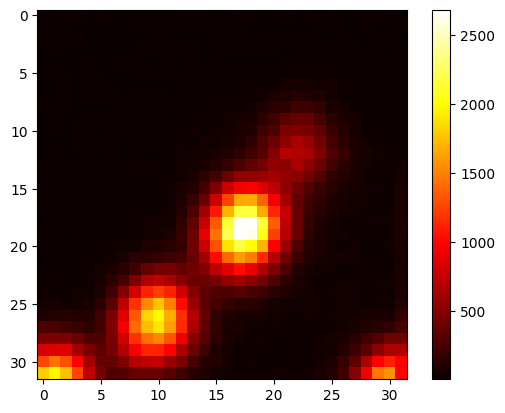

In [14]:
# RUN INPUT
#############################################################################################

#############################################################################################
# FILE IMPORT AND SETUP
############################################################################################

dir = os.getcwd()
filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output
savenameSOFI = path.join(dir,'images','output','SOFI',file)

timeSwitch = True #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]

# Read the TIFF stack
IMAGE_STACK = tiff.imread(filename) # (z, x, y)

if file == 'Qdots_FOV5um_64x64_5msPixel_23rip_37mW.tif':
    IMAGE_STACK = IMAGE_STACK[0:23,:,:]  # Select frames 0-22


# print(IMAGE_STACK.shape)
plt.imshow(IMAGE_STACK.sum(axis=0),cmap='hot')
plt.colorbar()
#plt.imshow(data.std(axis=0),cmap='hot')
plt.show()

In [15]:
# print(IMAGE_STACK.sum(axis=(1,2)).shape)
# print(IMAGE_STACK.mean(axis=0).sum(axis=(0,1)))
# plt.show()

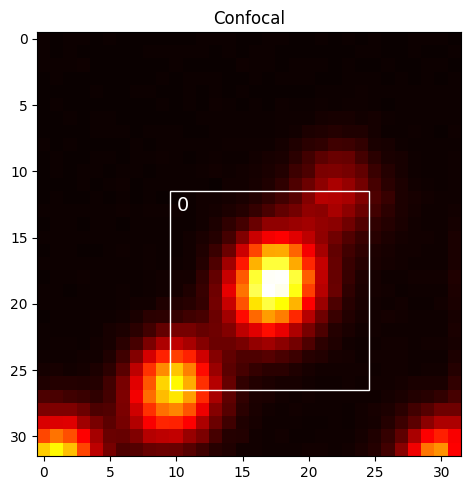

c:\Users\jocar\Desktop\tesi\images\2025 07 07-08 Qdots\Qdots_32x32_2e5um_60x_24mW_770nm_600frame_1msPixel.tif


In [16]:
# find peaks

img_STACK = IMAGE_STACK.sum(axis=0)

ROIsizeC = 15 # size of the ROI box
radius = ROIsizeC//2
signal_thresh_STACK = np.mean(img_STACK)


xc_STACK=peak_local_max(img_STACK,min_distance=radius, threshold_abs=signal_thresh_STACK) # cordinates peaks
# maxvalues = np.array([img_SPAD[xc_SPAD[i,0],xc_SPAD[i,1]] for i in range(xc_SPAD.shape[0])])

# if xc_SPAD.shape != xc_D1.shape:
#     raise "xc_D1 != xc_SPAD ha trovato più elementi in uno dei due"

Npart1 = xc_STACK.shape[0]
images = [img_STACK]

fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))

coords = [xc_STACK]
nparts = [Npart1]
titles = ['Confocal']

axes = [axes]
for i in range(len(images)):
    ax = axes[i]
    ax.imshow(images[i], cmap='hot')
    ax.set_title(titles[i])
    for l in range(nparts[i]):
        rect = Rectangle((coords[i][l,1]-ROIsizeC/2, coords[i][l,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=1, edgecolor='w', facecolor='none')
        ax.add_patch(rect)
        ax.text(coords[i][l,1]-radius, coords[i][l,0]-radius+1, l, fontsize=14, color='white')
plt.tight_layout()
plt.show()

print(filename)

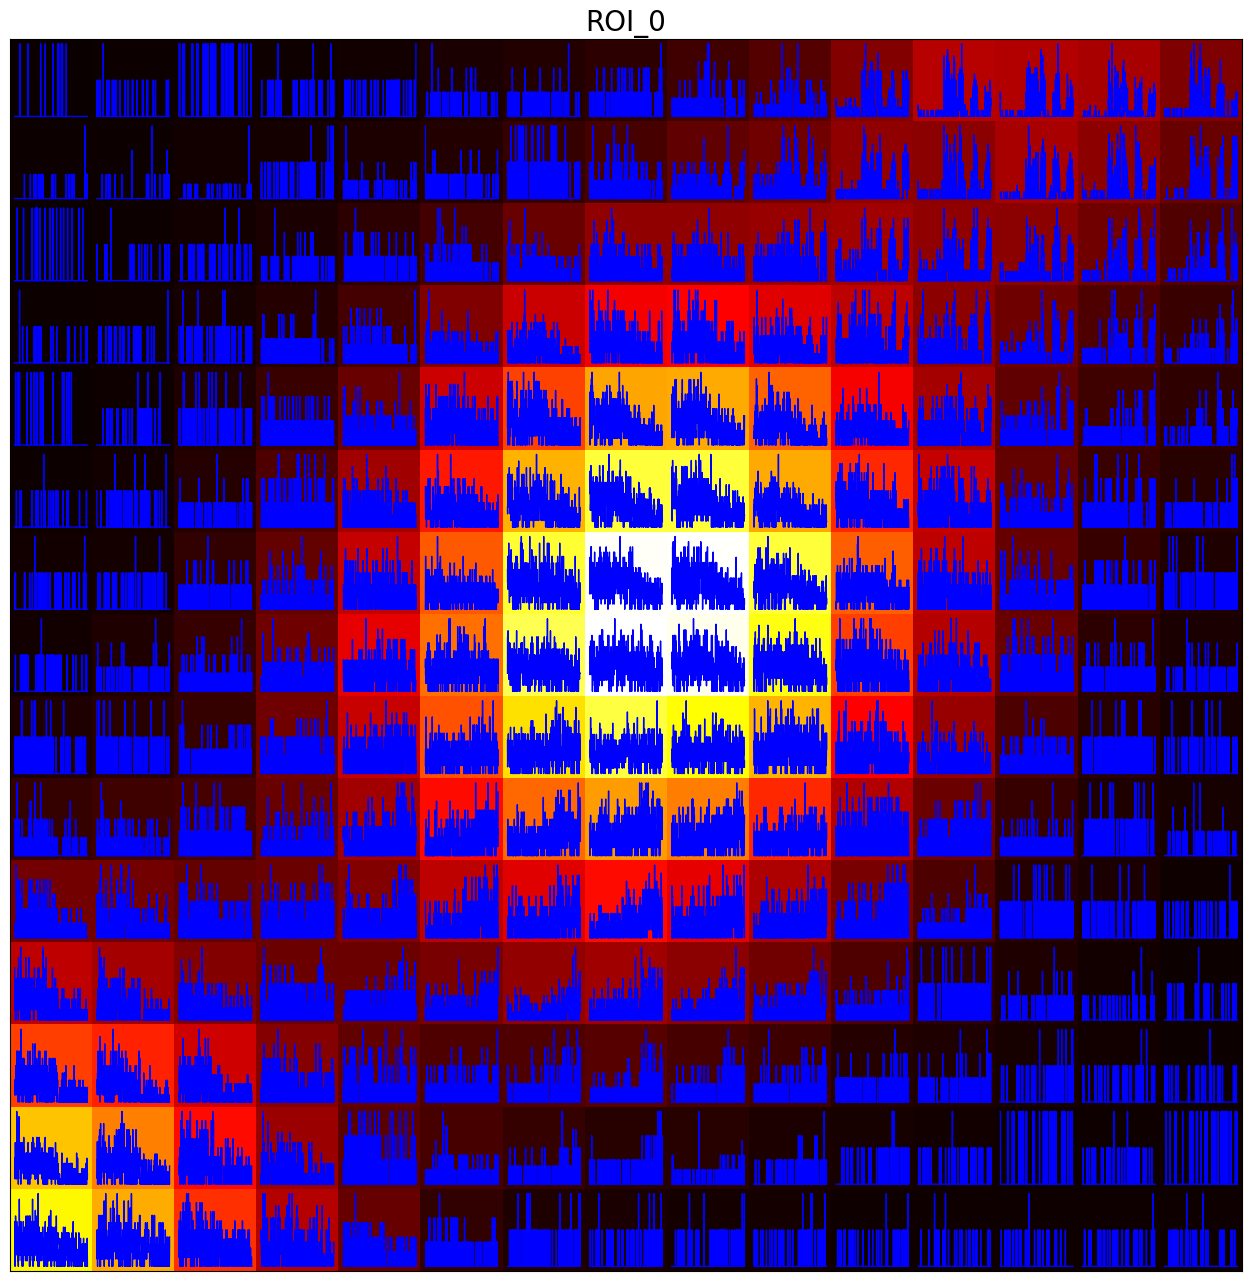

In [17]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ROI_0 = IMAGE_STACK[:, xc_STACK[0,0]-ROIsizeC//2:xc_STACK[0,0]+ROIsizeC//2+1, xc_STACK[0,1]-ROIsizeC//2:xc_STACK[0,1]+ROIsizeC//2+1]
# ROI_1 = IMAGE_STACK[:, xc_STACK[1,0]-ROIsizeC//2:xc_STACK[1,0]+ROIsizeC//2+1, xc_STACK[1,1]-ROIsizeC//2:xc_STACK[1,1]+ROIsizeC//2+1]
# ROI_2 = IMAGE_STACK[:, xc_STACK[2,0]-ROIsizeC//2:xc_STACK[2,0]+ROIsizeC//2+1, xc_STACK[2,1]-ROIsizeC//2:xc_STACK[2,1]+ROIsizeC//2+1]
# ROI_3 = IMAGE_STACK[:, xc_STACK[3,0]-ROIsizeC//2:xc_STACK[3,0]+ROIsizeC//2+1, xc_STACK[3,1]-ROIsizeC//2:xc_STACK[3,1]+ROIsizeC//2+1]
# ROI_4 = IMAGE_STACK[:, xc_STACK[4,0]-ROIsizeC//2:xc_STACK[4,0]+ROIsizeC//2+1, xc_STACK[4,1]-ROIsizeC//2:xc_STACK[4,1]+ROIsizeC//2+1]

fig, axes = plt.subplots(1, Npart1, figsize=(16*Npart1, 16))
for idx in range(1): #Npart1):
    ROI = locals()[f'ROI_{idx}']
    ax = axes[idx] if Npart1 > 1 else axes
    im = ax.imshow(ROI.sum(axis=0), cmap='hot')
    ax.set_title(f'ROI_{idx}',fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    n_z, n_pixels_y, n_pixels_x = ROI.shape
    for i in range(n_pixels_y):
        for j in range(n_pixels_x):
            axins = inset_axes(ax,
                               width=0.80, height=0.80,
                               loc='center',
                               bbox_to_anchor=(j + 0.5 - 1, i + 0.5 - 1, 1, 1),
                               bbox_transform=ax.transData,
                               borderpad=0)
            x = np.arange(0, n_z, 1)
            y = ROI[:, i, j]
            axins.plot(x, y, color='blue', linewidth=1)
            axins.set_facecolor('none')
            axins.axis('off')
plt.show()


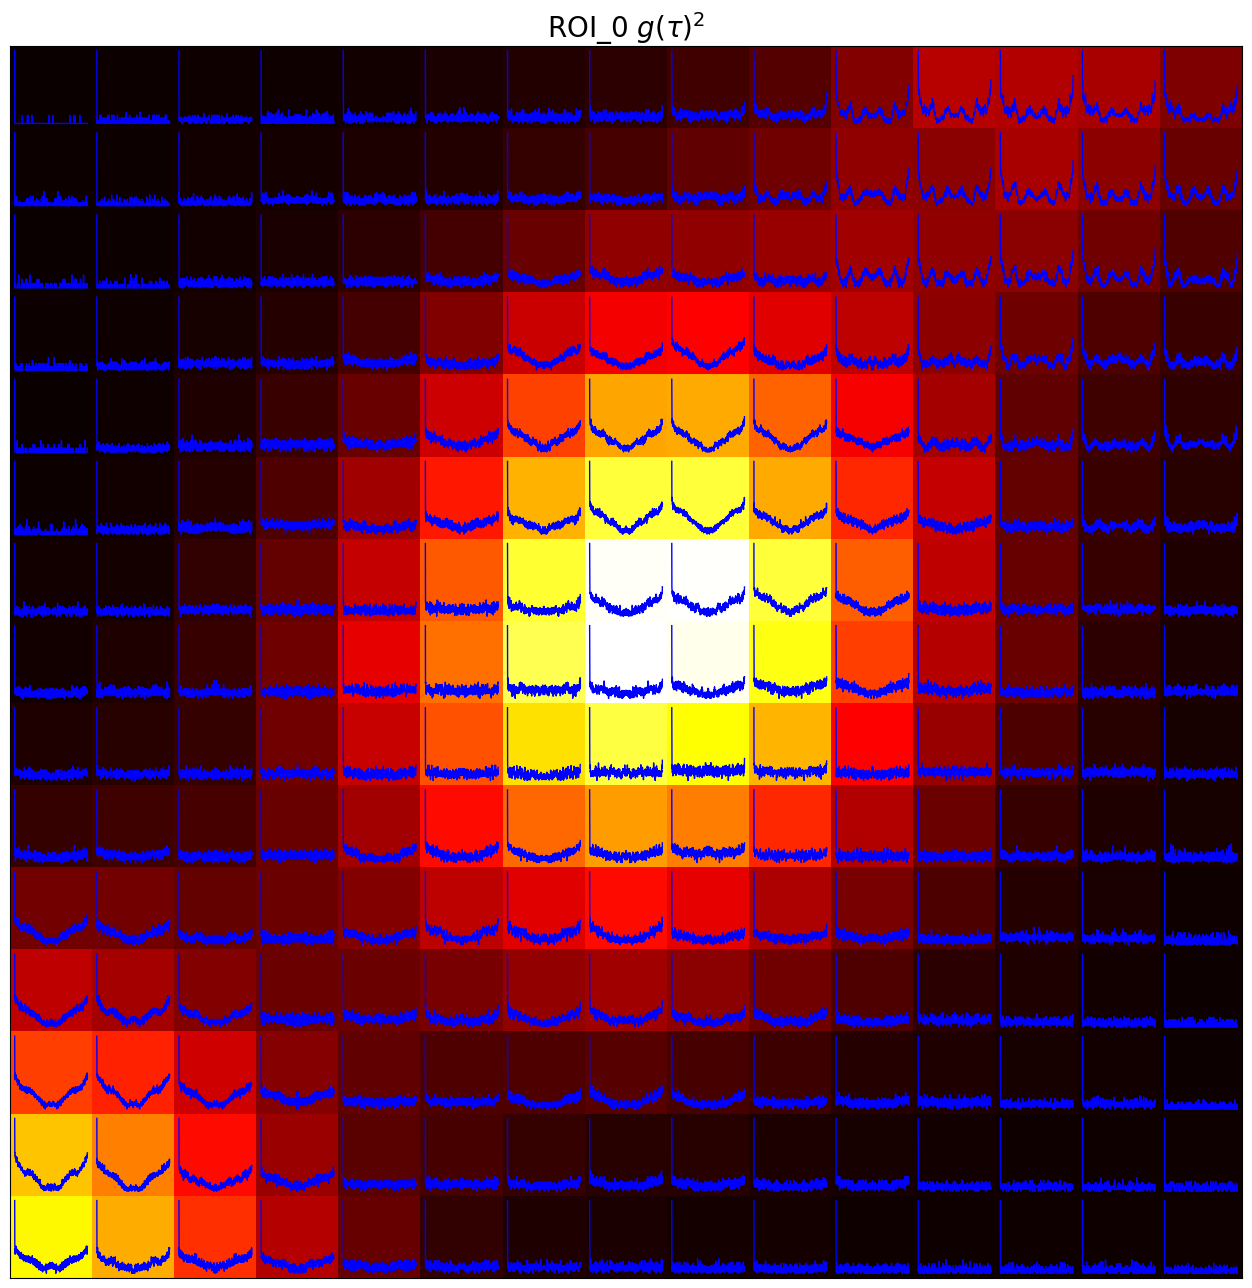

In [18]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(1, Npart1, figsize=(16*Npart1, 16))
for roi_idx in range(1): # Npart1):
    ROI = locals()[f'ROI_{roi_idx}']
    ax = axes[roi_idx] if Npart1 > 1 else axes
    im = ax.imshow(ROI.sum(axis=0), cmap='hot')
    ax.set_title(f'ROI_{roi_idx} $g(\\tau)^2$',fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])

    def correlazione(signal):
        t = signal - np.mean(signal)
        fft_t = np.fft.fft(t)
        fft_t_c = np.conjugate(fft_t)
        crosscorr = np.real(np.fft.ifft(fft_t * fft_t_c))
        return crosscorr

    ROI_correlated = ROI.copy()
    n_z, n_pixels_y, n_pixels_x = ROI.shape

    for i in range(n_pixels_y):
        for j in range(n_pixels_x):
            ROI_correlated[:, i, j] = correlazione(ROI[:, i, j])

    # print(f"ROI_{roi_idx}_correlated shape:", ROI_correlated.shape)

    for i in range(n_pixels_y):
        for j in range(n_pixels_x):
            axins = inset_axes(ax,
                               width=0.80, height=0.80,
                               loc='center',
                               bbox_to_anchor=(j + 0.5 - 1, i + 0.5 - 1, 1, 1),
                               bbox_transform=ax.transData,
                               borderpad=0)
            x = np.arange(0, n_z, 1)
            y = ROI_correlated[:, i, j]
            axins.plot(x, y, color='blue', linewidth=1)
            axins.set_facecolor('none')
            axins.axis('off')

plt.show()

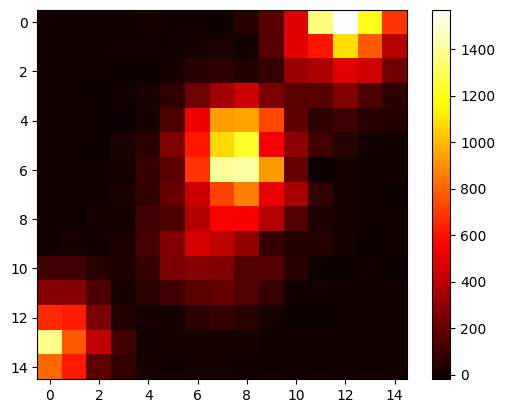

In [19]:
# plt.plot(ROI_correlated.sum(axis=(1,2)), color='blue', linewidth=2)
# # plt.yscale('log')
# plt.xlim(0, 100)
# plt.show()

plt.imshow(ROI_correlated[1,:,:],cmap='hot')
plt.colorbar()
plt.show()

C:\Users\jocar\AppData\Local\Temp\ipykernel_20256\105186804.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)
C:\Users\jocar\AppData\Local\Temp\ipykernel_20256\105186804.py:16: RuntimeWarning: overflow encountered in exp
  popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)
C:\Users\jocar\AppData\Local\Temp\ipykernel_20256\105186804.py:16: RuntimeWarning: overflow encountered in multiply
  popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)


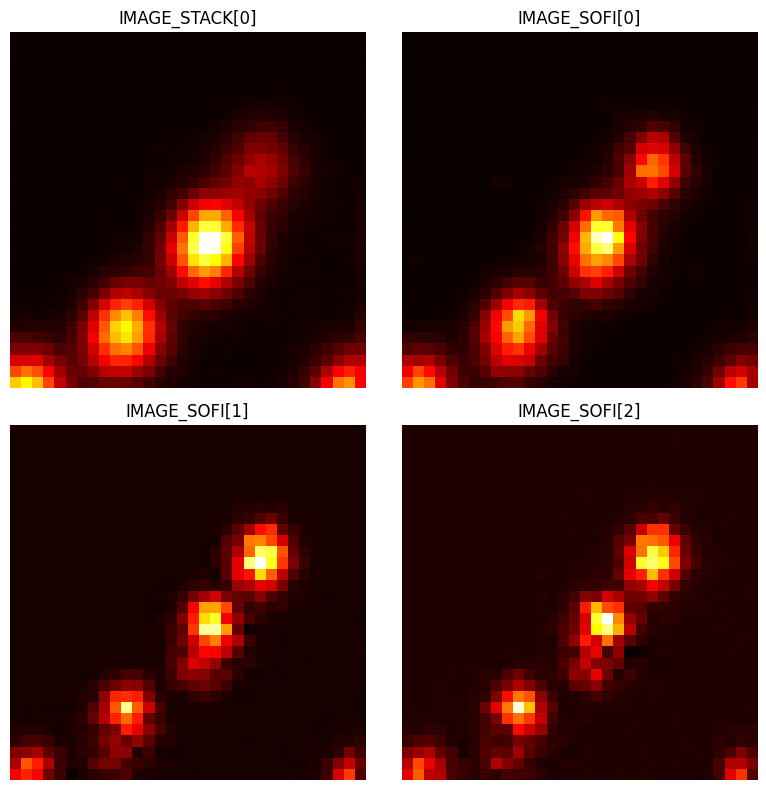

In [20]:
# IMAGE STACK VS IMAGE SOFI
def correlazione(signal):
        t = signal - np.mean(signal)
        fft_t = np.fft.fft(t)
        fft_t_c = np.conjugate(fft_t)
        crosscorr = np.real(np.fft.ifft(fft_t * fft_t_c))
        return crosscorr
IMAGE_SOFI = np.zeros_like(IMAGE_STACK)

taus = np.zeros(IMAGE_STACK.shape[0])

for i in range(IMAGE_STACK.shape[1]):
    for j in range(IMAGE_STACK.shape[2]):
        IMAGE_SOFI[:, i, j] = correlazione(IMAGE_STACK[:, i, j])
        try:
            popt,pcov = sc.optimize.curve_fit(lambda t, τ, A, B: A*np.exp(-t/τ) + B, np.arange(0,100), IMAGE_SOFI[:, i, j][0:100], p0=(10, 1000, 100), maxfev=10000)
        except:
            popt = [np.nan, np.nan, np.nan]
        taus[i] = popt[0]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))

axs[0, 0].imshow(IMAGE_STACK.sum(axis=0), cmap='hot')
axs[0, 0].set_title('IMAGE_STACK[0]')
axs[0, 0].axis('off')

axs[0, 1].imshow(IMAGE_SOFI[0, :, :], cmap='hot')
axs[0, 1].set_title('IMAGE_SOFI[0]')
axs[0, 1].axis('off')

axs[1, 0].imshow(IMAGE_SOFI[1, :, :], cmap='hot')
axs[1, 0].set_title('IMAGE_SOFI[1]')
axs[1, 0].axis('off')

axs[1, 1].imshow(IMAGE_SOFI[2, :, :], cmap='hot')
axs[1, 1].set_title('IMAGE_SOFI[2]')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


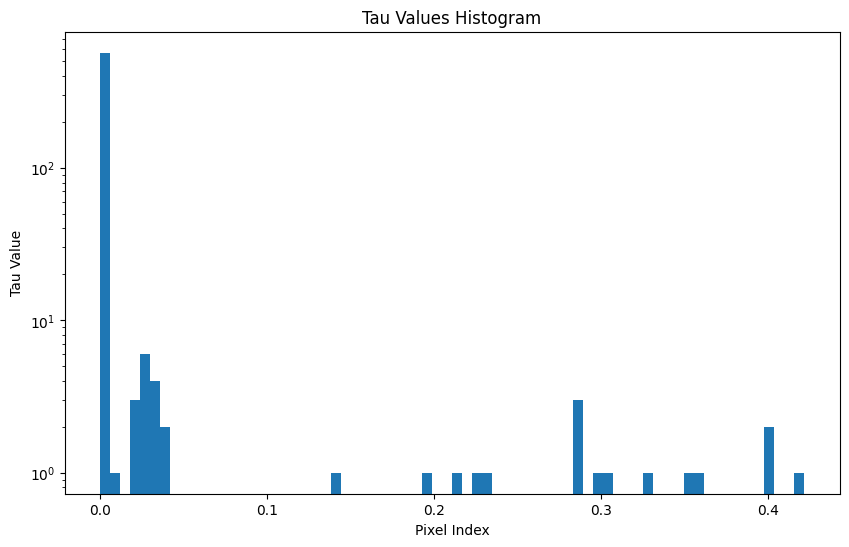

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(taus, bins=70)
plt.yscale('log')
plt.xlabel('Pixel Index')
plt.ylabel('Tau Value')
plt.title('Tau Values Histogram')
plt.show()

In [22]:

def erfC(x, amp, xc, w, offset): 
    return amp*np.pi*w*w*(1-scipy.special.erf((xc-x)/(np.sqrt(2.0)*w)))+offset*ROIsizeC*x # added minus sign

Δ = ROIsizeC // 2

ISM_DATAFRAME = pd.read_csv('./images/ISM/ISM_FWHM.csv')
    # Extract ROIs
    counter += 1
    # if counter > 1:
    #     break
    
    y,x = xc_SPAD[ROI_TO_ANALYSE['ROI_SPAD'][i]]
    index_ROI_CENTRAL_SPAD = ROI_TO_ANALYSE['ROI_SPAD'][i]
    ROI_SPAD = img_SPAD[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    y,x = xc_D1[ROI_TO_ANALYSE['ROI_D1'][i]]
    index_ROI_CENTRAL_D1 = ROI_TO_ANALYSE['ROI_D1'][i]
    ROI_D1 = img_D1[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    y,x = xc_D3[ROI_TO_ANALYSE['ROI_D3'][i]]
    index_ROI_CENTRAL_D3 = ROI_TO_ANALYSE['ROI_D3'][i]
    ROI_D3 = img_D3[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    y,x = xc_D5[ROI_TO_ANALYSE['ROI_D5'][i]]
    index_ROI_CENTRAL_D5 = ROI_TO_ANALYSE['ROI_D5'][i]
    ROI_D5 = img_D5[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    y,x = xc_D7[ROI_TO_ANALYSE['ROI_D7'][i]]
    index_ROI_CENTRAL_D7 = ROI_TO_ANALYSE['ROI_D7'][i]
    ROI_D7 = img_D7[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    # fit with CDF:
    # Define colors for each ROI
    colors = {
        'ROI_SPAD': 'tab:blue',
        'ROI_D1': 'tab:orange',
        'ROI_D3': 'tab:green',
        'ROI_D5': 'tab:red',
        'ROI_D7': 'tab:purple'
    }

    limits = ([0, 0, 0, -np.inf], [np.inf, ROIsizeC, np.inf, np.inf])

    X = np.cumsum(ROI_SPAD.sum(axis=1))
    # plt.plot(X, label='ROI_SPAD', color=colors['ROI_SPAD'])
    popt_SPAD, pcov_SPAD = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[-1], ROIsizeC/2, 2., 0.],bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_SPAD), '--', label='Fit SPAD', color=colors['ROI_SPAD'])
    FWHM_SPAD = np.round(2.355 * popt_SPAD[2],4)
    sigma_FWHM_SPAD = np.round(2.355 * np.sqrt(np.diag(pcov_SPAD))[2],4)
    print('FWHM SPAD: (' + str(np.round(FWHM_SPAD,2)) + '±' + str(np.round(sigma_FWHM_SPAD,2)) + ') px')

    X = np.cumsum(ROI_D1.sum(axis=1))
    # plt.plot(X, label='ROI_D1', color=colors['ROI_D1'])
    popt_D1, pcov_D1 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=popt_SPAD, bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D1), '--', label='Fit D1', color=colors['ROI_D1'])
    FWHM_D1 = np.round(2.355 * popt_D1[2],4)
    sigma_FWHM_D1 = np.round(2.355 * np.sqrt(np.diag(pcov_D1))[2],4)
    print('FWHM D1: (' + str(np.round(FWHM_D1,2)) + '±' + str(np.round(sigma_FWHM_D1,2)) + ') px')

    X = np.cumsum(ROI_D3.sum(axis=1))
    # plt.plot(X, label='ROI_D3', color=colors['ROI_D3'])
    popt_D3, pcov_D3 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D3), '--', label='Fit D3', color=colors['ROI_D3'])
    FWHM_D3 = np.round(2.355 * popt_D3[2],4)
    sigma_FWHM_D3 = np.round(2.355 * np.sqrt(np.diag(pcov_D3))[2],4)
    print('FWHM D3: (' + str(np.round(FWHM_D3,2)) + '±' + str(np.round(sigma_FWHM_D3,2)) + ') px')

    X = np.cumsum(ROI_D5.sum(axis=1))
    # plt.plot(X, label='ROI_D5', color=colors['ROI_D5'])
    popt_D5, pcov_D5 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D5), '--', label='Fit D5', color=colors['ROI_D5'])
    FWHM_D5 = np.round(2.355 * popt_D5[2],4)
    sigma_FWHM_D5 = np.round(2.355 * np.sqrt(np.diag(pcov_D5))[2],4)
    print('FWHM D5: (' + str(np.round(FWHM_D5,2)) + '±' + str(np.round(sigma_FWHM_D5,2)) + ') px')

    X = np.cumsum(ROI_D7.sum(axis=1))
    # plt.plot(X, label='ROI_D7', color=colors['ROI_D7'])
    popt_D7, pcov_D7 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D7), '--', label='Fit D7', color=colors['ROI_D7'])
    FWHM_D7 = np.round(2.355 * popt_D7[2],4)
    sigma_FWHM_D7 = np.round(2.355 * np.sqrt(np.diag(pcov_D7))[2],4)
    print('FWHM D7: (' + str(np.round(FWHM_D7,2)) + '±' + str(np.round(sigma_FWHM_D7,2)) + ') px')
    print({
        'CENTRAL SPAD': FWHM_SPAD,
        'ISM_D1': FWHM_D1,
        'ISM_D3': FWHM_D3,
        'ISM_D5': FWHM_D5,
        'ISM_D7': FWHM_D7,
        'err CENTAL SPAD': sigma_FWHM_SPAD,
        'err ISM_D1': sigma_FWHM_D1,
        'err ISM_D3': sigma_FWHM_D3,
        'err ISM_D5': sigma_FWHM_D5,
        'err ISM_D7': sigma_FWHM_D7,
        'FILE': file,
        'ROI CENTRAL SPAD': index_ROI_CENTRAL_SPAD,
        'ROI ISM_D1': index_ROI_CENTRAL_D1,
        'ROI ISM_D3': index_ROI_CENTRAL_D3,
        'ROI ISM_D5': index_ROI_CENTRAL_D5,
        'ROI ISM_D7': index_ROI_CENTRAL_D7
    })
    print('\n')
    # CENTRAL SPAD, ISM_D1, ISM_D3, ISM_D5, ISM_D7, err CENTAL SPAD, err ISM_D1, err ISM_D3, err ISM_D5, err ISM_D7,FILE,ROI CENTRAL SPAD, ROI ISM_D1, ROI ISM_D3, ROI ISM_D5, ROI ISM_D7
    ISM_DATAFRAME.loc[len(ISM_DATAFRAME)] = {
        'CENTRAL SPAD': float(FWHM_SPAD),
        'ISM_D1': float(FWHM_D1),
        'ISM_D3': float(FWHM_D3),
        'ISM_D5': float(FWHM_D5),
        'ISM_D7': float(FWHM_D7),
        'err CENTAL SPAD': float(sigma_FWHM_SPAD),
        'err ISM_D1': float(sigma_FWHM_D1),
        'err ISM_D3': float(sigma_FWHM_D3),
        'err ISM_D5': float(sigma_FWHM_D5),
        'err ISM_D7': float(sigma_FWHM_D7),
        'FILE': str(file),
        'ROI CENTRAL SPAD': int(index_ROI_CENTRAL_SPAD),
        'ROI ISM_D1': int(index_ROI_CENTRAL_D1),
        'ROI ISM_D3': int(index_ROI_CENTRAL_D3),
        'ROI ISM_D5': int(index_ROI_CENTRAL_D5),
        'ROI ISM_D7': int(index_ROI_CENTRAL_D7)
    }

display(ISM_DATAFRAME)

# ISM_DATAFRAME.to_csv('./images/ISM/ISM_FWHM.csv', index=False)


IndentationError: unexpected indent (803174894.py, line 8)